In [32]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [33]:
# Data paths
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32

In [34]:
# Data generators with STRONG augmentation
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Validation should only rescale
val_datagen = ImageDataGenerator(
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.


In [35]:
print(val_generator.class_indices)

{'Black Sea Sprat': 0, 'Gilt-Head Bream': 1, 'Hourse Mackerel': 2, 'Red Mullet': 3, 'Red Sea Bream': 4, 'Sea Bass': 5, 'Shrimp': 6, 'Striped Red Mullet': 7, 'Trout': 8}


In [36]:
# Build model WITHOUT pre-trained weights + regularization
base_model = MobileNetV3Large(weights=None, include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(train_generator.num_classes, activation='softmax', 
                   kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [37]:
# Compile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
# Train with callbacks to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1777300024.478505 1210850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154791__.356


225/225 ━━━━━━━━━━━━━━━━━━━━ 180s 569ms/step - accuracy: 0.4508 - loss: 1.6559 - val_accuracy: 0.1111 - val_loss: 2.3689 - learning_rate: 1.0000e-04
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 109s 482ms/step - accuracy: 0.6967 - loss: 1.0051 - val_accuracy: 0.1111 - val_loss: 2.3640 - learning_rate: 1.0000e-04
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 113s 502ms/step - accuracy: 0.8119 - loss: 0.7009 - val_accuracy: 0.1111 - val_loss: 2.3629 - learning_rate: 1.0000e-04
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 114s 505ms/step - accuracy: 0.8604 - loss: 0.5443 - val_accuracy: 0.1111 - val_loss: 2.3634 - learning_rate: 1.0000e-04
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 112s 497ms/step - accuracy: 0.9003 - loss: 0.4279 - val_accuracy: 0.1111 - val_loss: 2.3680 - learning_rate: 1.0000e-04
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 114s 505ms/step - accuracy: 0.9232 - loss: 0.3506 - val_accuracy: 0.1111 - val_loss: 2.3728 - learning_rate: 1.0000e-04
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 115s 509ms/

In [39]:
# Save model
from pathlib import Path

project_root = Path('/home/groggy/projects/Image-Classification-Explainability')
save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Basic_noImagenet.keras'
model.save(save_path)
print('Model saved to disk.')

Model saved to disk.


## light analysis

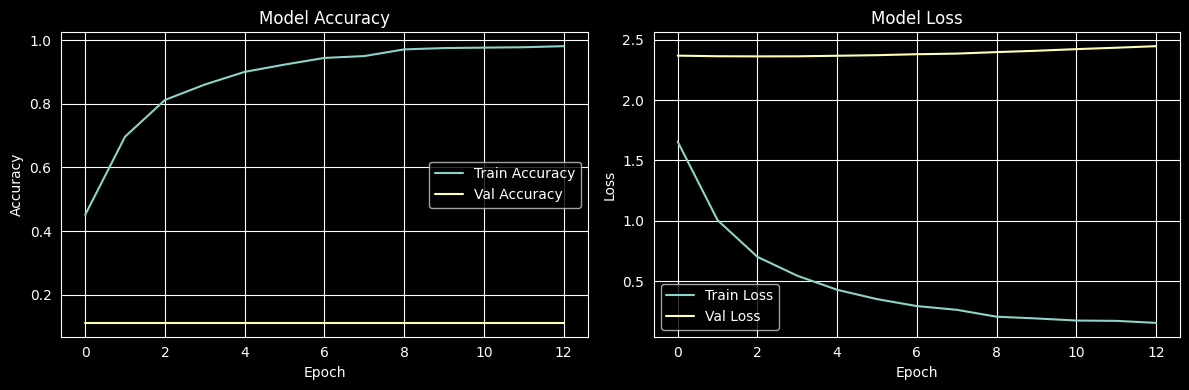

In [40]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()